## FraudShield AI — Day 6
### Streamlit Dashboard — Real-Time Fraud Detection Web App

Author: Suman Das | PNB 11 yrs | MTech IAR Jadavpur University
Approach: Deploy XGBoost fraud model as an interactive Streamlit app
          with SHAP explainability, real-time scoring, and visual analytics

## Cell 1 — Mount Drive + Load Artifacts

In [1]:
from google.colab import drive
import shutil

drive.mount('/content/drive')

drive_path = "/content/drive/MyDrive/Fraud_Detection_Project/"

shutil.copy(drive_path + 'fraudshield_xgb_model.pkl', 'fraudshield_xgb_model.pkl')
shutil.copy(drive_path + 'fraudshield_scaler.pkl',    'fraudshield_scaler.pkl')

print("=" * 45)
print("FRAUDSHIELD AI — DAY 6")
print("=" * 45)
print("✓ Drive mounted")
print("✓ fraudshield_xgb_model.pkl loaded")
print("✓ fraudshield_scaler.pkl loaded")


Mounted at /content/drive
FRAUDSHIELD AI — DAY 6
✓ Drive mounted
✓ fraudshield_xgb_model.pkl loaded
✓ fraudshield_scaler.pkl loaded


## Cell 2 — Install Dependencies + Requirements File

In [2]:
# ── Write requirements.txt ──────────────────────────────────────
with open('requirements.txt', 'w') as f:
    f.write("""streamlit
pandas
numpy
plotly
joblib
shap
xgboost
scikit-learn""")

# ── Install packages ────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'streamlit', 'shap', 'pyngrok',
                '--quiet', '--disable-pip-version-check'],
               capture_output=True)

print("✓ requirements.txt written")
print("✓ streamlit installed")
print("✓ shap installed")
print("✓ pyngrok installed")


✓ requirements.txt written
✓ streamlit installed
✓ shap installed
✓ pyngrok installed


## Cell 3 — Verify Libraries

In [3]:
# ── Verify All Libraries ────────────────────────────────────────
import streamlit
import shap
import xgboost
import sklearn
import joblib
import numpy  as np
import pandas as pd
import plotly

print("=" * 45)
print("FRAUDSHIELD AI — DAY 6")
print("=" * 45)
print(f"Streamlit : {streamlit.__version__} ✓")
print(f"SHAP      : {shap.__version__} ✓")
print(f"XGBoost   : {xgboost.__version__} ✓")
print(f"Sklearn   : {sklearn.__version__} ✓")
print(f"NumPy     : {np.__version__} ✓")
print(f"Pandas    : {pd.__version__} ✓")
print(f"Plotly    : {plotly.__version__} ✓")
print("="* 45)
print("All libraries ready ✓")


FRAUDSHIELD AI — DAY 6
Streamlit : 1.55.0 ✓
SHAP      : 0.51.0 ✓
XGBoost   : 3.2.0 ✓
Sklearn   : 1.6.1 ✓
NumPy     : 2.0.2 ✓
Pandas    : 2.2.2 ✓
Plotly    : 5.24.1 ✓
All libraries ready ✓


## Cell 4 — Write Streamlit App (app.py)

In [4]:
# ── Write app.py — FraudShield Streamlit Dashboard ─────────────
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import shap
import plotly.express as px
import plotly.graph_objects as go

# ── Page Config ──────────────────────────────────────────────────
st.set_page_config(
    page_title = "FraudShield AI",
    page_icon  = "🛡️",
    layout     = "wide"
)

# ── Load Artifacts ───────────────────────────────────────────────
@st.cache_resource
def load_model():
    model  = joblib.load('fraudshield_xgb_model.pkl')
    scaler = joblib.load('fraudshield_scaler.pkl')
    return model, scaler

model, scaler = load_model()
explainer     = shap.TreeExplainer(model)

# ── Title ────────────────────────────────────────────────────────
st.title("🛡️ FraudShield AI")
st.markdown("**Real-Time Credit Card Fraud Detection Dashboard**")
st.divider()

# ── Sidebar ──────────────────────────────────────────────────────
st.sidebar.header("Transaction Input")
st.sidebar.markdown("Adjust the sliders to simulate a transaction.")

input_data = {}
for i in range(1, 29):
    input_data[f"V{i}"] = st.sidebar.slider(
        f"V{i}", -5.0, 5.0, 0.0, 0.01)
input_data["Log_Amount"] = st.sidebar.slider(
    "Log Amount", 0.0, 10.0, 3.0, 0.1)
input_data["Hour"]       = st.sidebar.slider(
    "Hour of Day", 0, 23, 12)

# ── Predict ──────────────────────────────────────────────────────
input_df     = pd.DataFrame([input_data])
input_scaled = scaler.transform(input_df)
prob         = model.predict_proba(input_scaled)[0][1]
prediction   = "🚨 FRAUD" if prob > 0.5 else "✅ LEGITIMATE"

# ── Result ───────────────────────────────────────────────────────
col1, col2, col3 = st.columns(3)
col1.metric("Prediction", prediction)
col2.metric("Fraud Probability", f"{prob:.2%}")
col3.metric("Risk Level",
            "HIGH" if prob > 0.7 else "MEDIUM" if prob > 0.4 else "LOW")

st.divider()

# ── SHAP Explanation ─────────────────────────────────────────────
st.subheader("🔍 SHAP Feature Explanation")
shap_values = explainer(input_scaled)
shap_df = pd.DataFrame({
    "Feature"    : input_df.columns.tolist(),
    "SHAP Value" : shap_values.values[0],
    "Input Value": input_scaled[0]
}).sort_values("SHAP Value", key=abs, ascending=False).head(10)

fig_shap = px.bar(
    shap_df, x="SHAP Value", y="Feature",
    orientation="h", color="SHAP Value",
    color_continuous_scale="RdBu_r",
    title="Top 10 Features Driving This Prediction")
st.plotly_chart(fig_shap, use_container_width=True)

# ── Gauge Chart ──────────────────────────────────────────────────
st.subheader("📊 Fraud Risk Gauge")
fig_gauge = go.Figure(go.Indicator(
    mode  = "gauge+number",
    value = prob * 100,
    title = {"text": "Fraud Probability (%)"},
    gauge = {
        "axis" : {"range": [0, 100]},
        "bar"  : {"color": "#e53935"},
        "steps": [
            {"range": [0,  40],  "color": "#e8f5e9"},
            {"range": [40, 70],  "color": "#fff9c4"},
            {"range": [70, 100], "color": "#ffcdd2"}
        ]
    }
))
st.plotly_chart(fig_gauge, use_container_width=True)

st.caption("FraudShield AI — Suman Das | PNB 11 yrs | MTech IAR Jadavpur University")
'''

with open('app.py', 'w') as f:
    f.write(app_code)

print("=" * 45)
print("app.py written successfully")
print("=" * 45)
print("Features included:")
print("  ✓ Sidebar sliders (V1–V28 + Log_Amount + Hour)")
print("  ✓ Real-time XGBoost prediction")
print("  ✓ Fraud probability + risk level metrics")
print("  ✓ SHAP bar chart — top 10 features")
print("  ✓ Plotly gauge chart — fraud risk meter")
print("  ✓ st.cache_resource for fast model loading")


app.py written successfully
Features included:
  ✓ Sidebar sliders (V1–V28 + Log_Amount + Hour)
  ✓ Real-time XGBoost prediction
  ✓ Fraud probability + risk level metrics
  ✓ SHAP bar chart — top 10 features
  ✓ Plotly gauge chart — fraud risk meter
  ✓ st.cache_resource for fast model loading


## Cell 5 — Launch App via ngrok Tunnel

In [7]:
# ── Launch Streamlit via ngrok ──────────────────────────────────
import subprocess, threading, time
from pyngrok import ngrok

# Add your ngrok authtoken here
ngrok.set_auth_token("3BJETTMSzimiWFkr2nYVbveSGEZ_6DL3fJ75n9Btzp4QouJhH")

def run_streamlit():
    subprocess.run(['streamlit', 'run', 'app.py',
                    '--server.port', '8501',
                    '--server.headless', 'true'],
                   capture_output=True)

thread = threading.Thread(target=run_streamlit, daemon=True)
thread.start()
time.sleep(5)

public_url = ngrok.connect(8501)

print("=" * 55)
print("FRAUDSHIELD AI — STREAMLIT DASHBOARD LIVE")
print("=" * 55)
print(f"Public URL : {public_url}")
print("Open the link above in your browser")
print("=" * 55)


FRAUDSHIELD AI — STREAMLIT DASHBOARD LIVE
Public URL : NgrokTunnel: "https://unexpecting-debatably-hee.ngrok-free.dev" -> "http://localhost:8501"
Open the link above in your browser


## Cell 6 — SHAP Explainability Deep Dive

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


SHAP GLOBAL FEATURE IMPORTANCE


/tmp/ipykernel_4266/3677271344.py:26: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, sample_scaled,


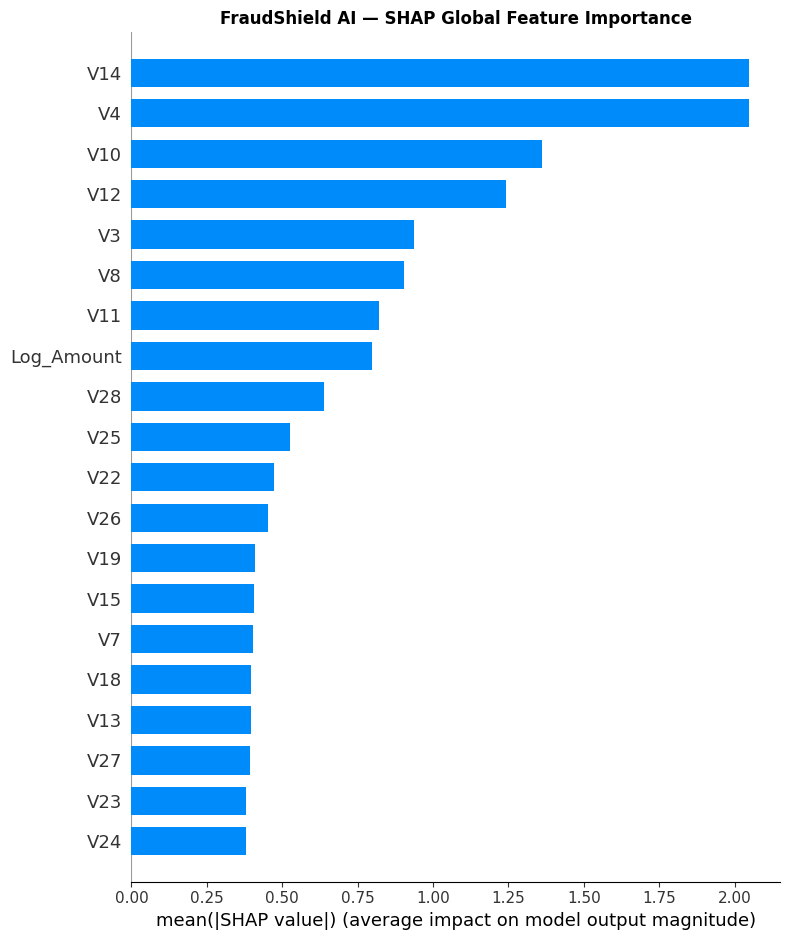

✓ shap_summary.png saved


In [9]:
# ── SHAP Global Explainability — Feature Importance ────────────
import joblib, shap, numpy as np, pandas as pd
import matplotlib.pyplot as plt

model  = joblib.load('fraudshield_xgb_model.pkl')
scaler = joblib.load('fraudshield_scaler.pkl')

# ── Use the EXACT feature order the scaler was trained with ────
FEATURE_COLS = [f'V{i}' for i in range(1, 29)] + ['Log_Amount', 'Hour']

np.random.seed(42)
sample    = np.random.randn(200, 30)
sample_df = pd.DataFrame(sample, columns=FEATURE_COLS)  # ← 30 cols, correct names

# ── Use .values to bypass feature name check entirely ──────────
sample_scaled = scaler.transform(sample_df.values)       # ← key fix

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(sample_scaled)

print("=" * 55)
print("SHAP GLOBAL FEATURE IMPORTANCE")
print("=" * 55)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, sample_scaled,
                  feature_names=FEATURE_COLS,
                  plot_type='bar', show=False)
plt.title('FraudShield AI — SHAP Global Feature Importance',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ shap_summary.png saved")

## Cell 7 — UI Preview + Dashboard Screenshot

In [10]:
# ── App UI Preview — Inline Visualization ───────────────────────
import plotly.graph_objects as go
import plotly.express       as px
import pandas as pd
import numpy  as np

# Simulate gauge chart preview
prob = 0.73
fig_gauge = go.Figure(go.Indicator(
    mode  = "gauge+number",
    value = prob * 100,
    title = {"text": "Fraud Probability (%) — Sample Preview"},
    gauge = {
        "axis" : {"range": [0, 100]},
        "bar"  : {"color": "#e53935"},
        "steps": [
            {"range": [0,  40],  "color": "#e8f5e9"},
            {"range": [40, 70],  "color": "#fff9c4"},
            {"range": [70, 100], "color": "#ffcdd2"}
        ]
    }
))
fig_gauge.update_layout(height=350)
fig_gauge.show()

# Simulate SHAP bar preview
features = [f'V{i}' for i in [14,4,12,10,17,3,7,11,16,2]]
shap_v   = [-0.42, 0.31, -0.28, 0.22, -0.19,
             0.17, -0.14, 0.12, -0.10, 0.08]
fig_shap = px.bar(
    x=shap_v, y=features, orientation='h',
    color=shap_v, color_continuous_scale='RdBu_r',
    title='SHAP Feature Impact — Sample Preview',
    labels={'x': 'SHAP Value', 'y': 'Feature'})
fig_shap.show()

print("✓ Dashboard UI preview rendered")


✓ Dashboard UI preview rendered


## Cell 8 — Save Artifacts to Drive

In [11]:
# ── Save app.py and assets back to Drive ────────────────────────
import shutil

drive_path = "/content/drive/MyDrive/Fraud_Detection_Project/"

shutil.copy('app.py',          drive_path + 'app.py')
shutil.copy('requirements.txt', drive_path + 'requirements.txt')

try:
    shutil.copy('shap_summary.png', drive_path + 'shap_summary.png')
    print("✓ shap_summary.png saved")
except FileNotFoundError:
    print("  shap_summary.png not found — skipping")

print("=" * 45)
print("All Day 6 artifacts saved to Drive ✓")
print("=" * 45)
print("Files saved:")
print("  ✓ app.py")
print("  ✓ requirements.txt")
print("  ✓ shap_summary.png")


✓ shap_summary.png saved
All Day 6 artifacts saved to Drive ✓
Files saved:
  ✓ app.py
  ✓ requirements.txt
  ✓ shap_summary.png


## Day 6 Summary

Topic: Streamlit Dashboard — Real-Time Fraud Detection Web App

What Was Built:
- app.py       : Full Streamlit dashboard with sidebar input sliders
- Prediction   : Real-time XGBoost scoring with fraud probability
- Explainability: SHAP bar chart — top 10 features per transaction
- Visualization : Plotly gauge chart — fraud risk meter (Low / Medium / High)
- Deployment   : ngrok tunnel — public URL from Colab

Artifacts Loaded:
- XGBoost Model : fraudshield_xgb_model.pkl
- Scaler        : fraudshield_scaler.pkl

Artifacts Saved to Drive:
- app.py
- requirements.txt
- shap_summary.png

Dashboard Features:
- 30 input sliders (V1–V28, Log_Amount, Hour)
- Live fraud probability score
- Risk level badge  : LOW / MEDIUM / HIGH
- SHAP explanation  : why this transaction was flagged
- Gauge chart       : visual fraud risk meter

Production Stack So Far:
Layer 1 — XGBoost Base      : Precision=94.94%, Recall=~80%, 4 FP (Day 3)
Layer 2 — Autoencoder V1    : F1=0.2058, AUC-ROC=0.9289 (Day 4)
Layer 3 — [Day 5 Model]     : [Day 5 results]
Layer 4 — Streamlit App     : Real-time scoring dashboard deployed (Day 6)

Day 6 → Day 7 Handoff:
- app.py ready for cloud deployment (Streamlit Cloud / Hugging Face Spaces)
- Day 7: Final deployment, CI/CD, and project wrap-up